# Ecommerce Project

You just got some contract work with an Ecommerce company based in New York City that sells clothing online but they also have in-store style and clothing advice sessions. Customers come in to the store, have sessions/meetings with a personal stylist, then they can go home and order either on a mobile app or website for the clothes they want.

The company is trying to decide whether to focus their efforts on their mobile app experience or their website. They've hired you on contract to help them figure it out! Let's get started!

Just follow the steps below to analyze the customer data (it's fake, don't worry I didn't give you real credit card numbers or emails).

## Imports
**Import pandas, numpy, matplotlib,and seaborn. Then set %matplotlib inline 
(You'll import sklearn as you need it.)**

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Get the Data

We'll work with the **Ecommerce_Customers.csv** file from the company. It includes Customer information, such as Email, Address, and their Avatar color, along with other numerical features such as:

* Avg. Session Length: Average session of in-store style advice sessions.
* Time on App: Average time spent on App in minutes
* Time on Website: Average time spent on Website in minutes
* Length of Membership: How many years the customer has been a member. 

**Read in the Ecommerce Customers csv file as a DataFrame called customers.**

In [76]:
df = pd.read_csv('Ecommerce_Customers.csv')
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## EDA Exploratory Data Analysis:
**Check the head of customers, and check out its info() and describe() methods. Do you need to clean you data?**

In [77]:
df.describe()
df.info()
#Grace a ces commandes nous pouvons comprendre les différentes colonnes et leurs types de données, ainsi que vérifier qu'il n'y a aucune valeur manquante dans le dataset.

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 69.3 KB


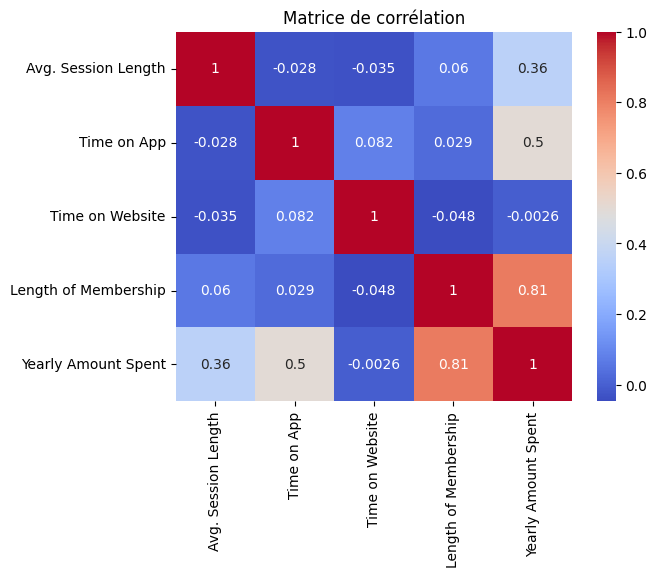

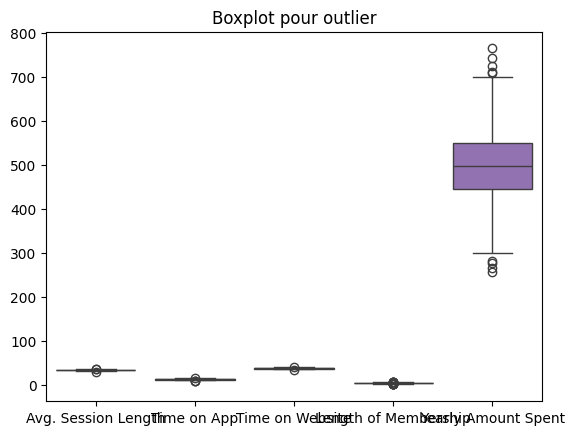

In [78]:
#Pour continuer notre EDA nous allons ajouter des annalyses pour avoir des données les plus optimiser pour notre entrainemnt.

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

sns.boxplot(df)
plt.title('Boxplot pour outlier')
plt.show()

on peut voir gravce a la matrice de correlation que la durée d'adhèsion est la variables la plus impactante, ensuite avec le boxplot on n'appercois des outliars mais rien d'aberrant. 

## Training and Testing Data

Now that we've explored the data a bit, let's go ahead and split the data into training and testing sets.
** Set a variable X equal to the numerical features of the customers and a variable y equal to the "Yearly Amount Spent" column. **

**Use model_selection.train_test_split from sklearn to split the data into training and testing sets. Set test_size=0.3 and random_state=101**

In [79]:
from sklearn.model_selection import train_test_split

X = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df[['Yearly Amount Spent']]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)
X_train

,Avg. Session Length,Time on App,Time on Website,Length of Membership
202,31.525752,11.340036,37.039514,3.811248
428,31.862741,14.039867,37.022269,3.738225
392,33.258238,11.514949,37.128039,4.662845
86,33.877779,12.517666,37.151921,2.669942
443,33.025020,12.504220,37.645839,4.051382
...,...,...,...,...
63,32.789773,11.670066,37.408748,3.414688
326,33.217188,10.999684,38.442767,4.243813
337,31.827979,12.461147,37.428997,2.974737
11,33.879361,11.584783,37.087926,3.713209


## Training the Model

Now its time to train our model on our training data!

**Import LinearRegression from sklearn.linear_model**

In [80]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [81]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

predictions = lm.predict(X_test)

SSE = np.sum((y_test - predictions) ** 2)
R2 = metrics.r2_score(y_test, predictions)

SSE, R2

(np.float64(11971.95774764614), 0.9890046246741234)

## Descente de gradient (SGDRegressor)

On utilise une descente de gradient stochastique pour tenter d'améliorer le MSE. Les features doivent être standardisées pour que le gradient converge correctement.

In [82]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

# Standardisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Descente de gradient stochastique
sgd = SGDRegressor(max_iter=10000, tol=1e-4, learning_rate='optimal', random_state=101)
sgd.fit(X_train_scaled, y_train.values.ravel())

# Predictions
sgd_predictions = sgd.predict(X_test_scaled)

# Comparaison avec LinearRegression
print('--- LinearRegression ---')
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('R2:', metrics.r2_score(y_test, predictions))

print('\n--- SGDRegressor (descente de gradient) ---')
print('MSE:', metrics.mean_squared_error(y_test, sgd_predictions))
print('R2:', metrics.r2_score(y_test, sgd_predictions))

--- LinearRegression ---
MSE: 79.81305165097427
R2: 0.9890046246741234

--- SGDRegressor (descente de gradient) ---
MSE: 3.5314695980873454e+23
R2: -4.8650982364008915e+19


**Create an instance of a LinearRegression() model named lm.**

**Train/fit lm on the training data.**

In [83]:
lm = LinearRegression()
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Print out the coefficients of the model**

In [84]:
# Ptint the coefficients
print('Coefficients: \n', lm.coef_)
# You can print the intercept as well:
# print('Intercept: \n', lm.intercept_)

Coefficients: 
 [[25.98154972 38.59015875  0.19040528 61.27909654]]


## Predicting Test Data
Now that we have fit our model, let's evaluate its performance by predicting off the test values!

**Use lm.predict() to predict off the X_test set of the data.**

In [85]:
predictions = lm.predict(X_test)
predictions

array([[456.44186104],
       [402.72005312],
       [409.2531539 ],
       [591.4310343 ],
       [590.01437275],
       [548.82396607],
       [577.59737969],
       [715.44428115],
       [473.7893446 ],
       [545.9211364 ],
       [337.8580314 ],
       [500.38506697],
       [552.93478041],
       [409.6038964 ],
       [765.52590754],
       [545.83973731],
       [693.25969124],
       [507.32416226],
       [573.10533175],
       [573.2076631 ],
       [397.44989709],
       [555.0985107 ],
       [458.19868141],
       [482.66899911],
       [559.2655959 ],
       [413.00946082],
       [532.25727408],
       [377.65464817],
       [535.0209653 ],
       [447.80070905],
       [595.54339577],
       [667.14347072],
       [511.96042791],
       [573.30433971],
       [505.02260887],
       [565.30254655],
       [460.38785393],
       [449.74727868],
       [422.87193429],
       [456.55615271],
       [598.10493696],
       [449.64517443],
       [615.34948995],
       [511

**Create a scatterplot of the real test values versus the predicted values.**

Text(0, 0.5, 'Predicted Y')

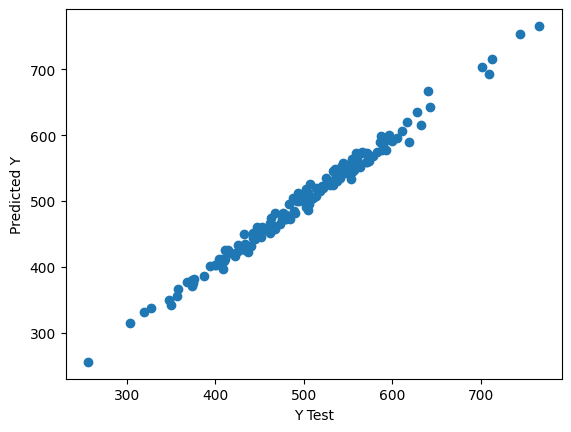

In [86]:
plt.scatter(y_test, predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

## Evaluating the Model

Let's evaluate our model performance by calculating the residual sum of squares and the explained variance score (R^2).

**Calculate the Mean Absolute Error, Mean Squared Error, and the Root Mean Squared Error. Refer to the lecture or to Wikipedia for the formulas**

## Regression Evaluation Metrics

Here are three common evaluation metrics for regression problems:

**Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) is the mean of the squared errors:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

Comparing these metrics:

- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

All of these are **loss functions**, because we want to minimize them.

In [87]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2:', metrics.r2_score(y_test, predictions))

MAE: 7.228148653430826
MSE: 79.81305165097427
RMSE: 8.933815066978624
R2: 0.9890046246741234


## Residuals

You should have gotten a very good model with a good fit. Let's quickly explore the residuals to make sure everything was okay with our data. 

**Plot a histogram of the residuals and make sure it looks normally distributed. Use either seaborn distplot, or just plt.hist().**

Text(0.5, 1.0, 'Distribution des résidus')

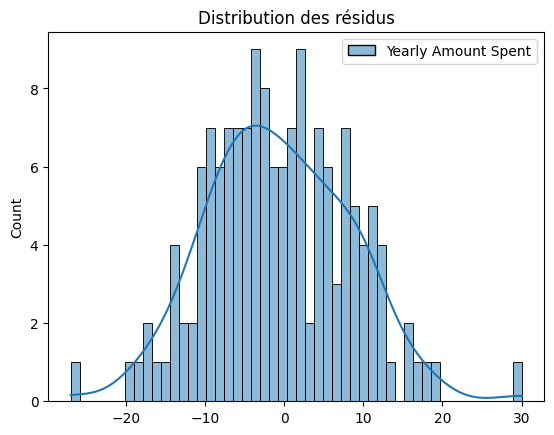

In [88]:
sns.histplot((y_test - predictions), bins=50, kde=True)
plt.title('Distribution des résidus')

## Conclusion
We still want to figure out the answer to the original question, do we focus our efforst on mobile app or website development? Or maybe that doesn't even really matter, and Membership Time is what is really important.  Let's see if we can interpret the coefficients at all to get an idea.

**Recreate the dataframe below.**
<img src="df.png" width=250 height=250 />

In [89]:
#write here you code & internal comments 
### solution1: coeffecients = pd.DataFrame(lm.coef_,index=X.columns, columns=['Coeffecient'])
### solution2:
#coeffecients = pd.DataFrame(lm.coef_,X.columns)
#coeffecients.columns = ['Coeffecient']
#print(coeffecients)

**How can you interpret these coefficients?**

Interprétation des coefficients :

- **Length of Membership (61.28)** : chaque année d'adhésion supplémentaire entraîne en moyenne 61.28$ de dépenses en plus. C'est le facteur le plus important.
- **Time on App (38.59)** : chaque minute supplémentaire passée sur l'app augmente les dépenses de 38.59$.
- **Avg. Session Length (25.98)** : chaque minute de session en magasin ajoute environ 25.98$.
- **Time on Website (0.19)** : le temps passé sur le site web n'a quasiment aucun impact sur les dépenses.

**Do you think the company should focus more on their mobile app or on their website?**

L'entreprise devrait concentrer ses efforts sur l'**application mobile**. Le coefficient du temps sur l'app (38.59) est largement supérieur à celui du site web (0.19), ce qui montre que l'app génère beaucoup plus de revenus. Deux options possibles :

1. **Investir davantage dans l'app** pour capitaliser sur ce qui fonctionne déjà bien.
2. **Améliorer le site web** qui est clairement sous-performant — peut-être qu'avec une meilleure expérience utilisateur, il pourrait rattraper l'app.

Dans les deux cas, la **fidélisation des membres** reste la priorité numéro un vu le coefficient dominant de Length of Membership (61.28).

## Great Job!

Congrats on your contract work! The company loved the insights! Let's move on.